<a href="https://colab.research.google.com/github/iisalaasonen/ML/blob/main/phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data is Phishing Websites Data Set from UCI Machine Learning Repository

In [ ]:
from pycaret.utils import enable_colab
enable_colab()

Colab mode activated.


In [ ]:
!pip install pycaret

In [ ]:
import pandas as pd
data = pd.read_csv("phishing.csv", delimiter=",")
data.drop(["Index"], axis=1, inplace=True)
print(data.shape)
print("Value Count of Class : ")
print(data["class"].value_counts())

(11054, 31)
Value Count of Class : 
 1    6157
-1    4897
Name: class, dtype: int64


In [ ]:
print(data.head())

   UsingIP  LongURL  ShortURL  ...  LinksPointingToPage  StatsReport  class
0        1        1         1  ...                    1            1     -1
1        1        0         1  ...                    0           -1     -1
2        1        0         1  ...                   -1            1     -1
3        1        0        -1  ...                    1            1      1
4       -1        0        -1  ...                   -1           -1      1

[5 rows x 31 columns]


In [ ]:
from pycaret.classification import *

In [ ]:
session = setup(data = data, target="class", session_id=123, experiment_name="Phishing websites")

Setup Succesfully Completed!


,Description,Value
0,session_id,123
1,Target Type,Binary
2,Label Encoded,"-1: 0, 1: 1"
3,Original Data,"(11054, 31)"
4,Missing Values,False
5,Numeric Features,0
6,Categorical Features,30
7,Ordinal Features,False
8,High Cardinality Features,False
9,High Cardinality Method,None


In [ ]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Extra Trees Classifier,0.9712,0.9897,0.9756,0.9727,0.9742,0.9416,0.9416,0.5527
1,CatBoost Classifier,0.9705,0.9962,0.9770,0.9703,0.9736,0.9402,0.9403,5.8230
2,Random Forest Classifier,0.9686,0.9916,0.9749,0.9689,0.9719,0.9363,0.9364,0.1132
3,Light Gradient Boosting Machine,0.9661,0.9957,0.9735,0.9661,0.9697,0.9313,0.9315,0.1829
4,Decision Tree Classifier,0.9602,0.9691,0.9654,0.9632,0.9643,0.9193,0.9193,0.0327
5,K Neighbors Classifier,0.9520,0.9880,0.9682,0.9469,0.9574,0.9025,0.9029,0.0818
6,Extreme Gradient Boosting,0.9517,0.9907,0.9657,0.9487,0.9570,0.9018,0.9021,0.9053
7,Gradient Boosting Classifier,0.9511,0.9908,0.9647,0.9486,0.9565,0.9008,0.9011,1.3030
8,Logistic Regression,0.9402,0.9872,0.9547,0.9390,0.9467,0.8785,0.8788,0.1851
9,Ada Boost Classifier,0.9382,0.9870,0.9552,0.9354,0.9451,0.8745,0.8749,0.4690


In [ ]:
et = create_model("et")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9716,0.9935,0.9814,0.9680,0.9747,0.9423,0.9424
1,0.9587,0.9806,0.9675,0.9586,0.9630,0.9161,0.9162
2,0.9767,0.9976,0.9768,0.9814,0.9791,0.9529,0.9529
3,0.9755,0.9931,0.9791,0.9769,0.9780,0.9502,0.9502
4,0.9755,0.9937,0.9768,0.9791,0.9779,0.9503,0.9503
5,0.9716,0.9846,0.9698,0.9789,0.9744,0.9425,0.9425
6,0.9767,0.9922,0.9814,0.9769,0.9792,0.9529,0.9529
7,0.9702,0.9869,0.9745,0.9722,0.9733,0.9397,0.9397
8,0.9677,0.9899,0.9745,0.9677,0.9711,0.9344,0.9344
9,0.9677,0.9846,0.9744,0.9677,0.9710,0.9344,0.9345


In [ ]:
tuned_et = tune_model(et)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.9199,0.9816,0.9606,0.9020,0.9303,0.8363,0.8386
1,0.9057,0.9695,0.9490,0.8891,0.9181,0.8072,0.8096
2,0.8941,0.9696,0.9466,0.8737,0.9087,0.7830,0.7866
3,0.9083,0.9775,0.9490,0.8930,0.9201,0.8126,0.8147
4,0.9096,0.9736,0.9420,0.9002,0.9206,0.8157,0.8168
5,0.8992,0.9757,0.9675,0.8669,0.9145,0.7927,0.7998
6,0.9251,0.9831,0.9582,0.9117,0.9344,0.8472,0.8486
7,0.8732,0.9660,0.9374,0.8505,0.8918,0.7396,0.7447
8,0.9030,0.9722,0.9745,0.8678,0.9180,0.8001,0.8082
9,0.9004,0.9758,0.9442,0.8845,0.9134,0.7965,0.7988


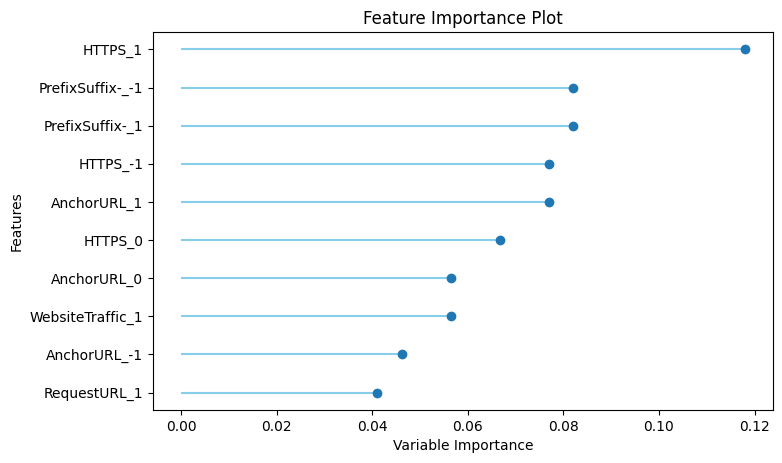

In [ ]:
plot_model(tuned_et, plot="feature")

In [ ]:
evaluate_model(tuned_et)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [ ]:
predict_model(tuned_et)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.902,0.9723,0.9508,0.8825,0.9153,0.7994,0.8026


,UsingIP_-1,UsingIP_1,LongURL_-1,LongURL_0,LongURL_1,ShortURL_-1,ShortURL_1,Symbol@_-1,Symbol@_1,Redirecting//_-1,Redirecting//_1,PrefixSuffix-_-1,PrefixSuffix-_1,SubDomains_-1,SubDomains_0,SubDomains_1,HTTPS_-1,HTTPS_0,HTTPS_1,DomainRegLen_-1,DomainRegLen_1,Favicon_-1,Favicon_1,NonStdPort_-1,NonStdPort_1,HTTPSDomainURL_-1,HTTPSDomainURL_1,RequestURL_-1,RequestURL_1,AnchorURL_-1,AnchorURL_0,AnchorURL_1,LinksInScriptTags_-1,LinksInScriptTags_0,LinksInScriptTags_1,ServerFormHandler_-1,ServerFormHandler_0,ServerFormHandler_1,InfoEmail_-1,InfoEmail_1,AbnormalURL_-1,AbnormalURL_1,WebsiteForwarding_0,WebsiteForwarding_1,StatusBarCust_-1,StatusBarCust_1,DisableRightClick_-1,DisableRightClick_1,UsingPopupWindow_-1,UsingPopupWindow_1,IframeRedirection_-1,IframeRedirection_1,AgeofDomain_-1,AgeofDomain_1,DNSRecording_-1,DNSRecording_1,WebsiteTraffic_-1,WebsiteTraffic_0,WebsiteTraffic_1,PageRank_-1,PageRank_1,GoogleIndex_-1,GoogleIndex_1,LinksPointingToPage_-1,LinksPointingToPage_0,LinksPointingToPage_1,StatsReport_-1,StatsReport_1,class,Label,Score
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1,-1,0.3929
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,1,0.7575
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1,-1,0.4820
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1,1,0.6959
4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1,1,0.6737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3312,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1,1,0.5062
3313,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-1,-1,0.3838
3314,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1,1,0.6083
3315,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-1,-1,0.4056


In [ ]:
final_et = finalize_model(tuned_et)

In [ ]:
save_model(final_et, "Phishing luokittelumalli 19Lokakuu2020")

Transformation Pipeline and Model Succesfully Saved
